In [1]:
%pip install matplotlib
%pip install tensorflow
%pip install scikit-learn
%pip install numpy
%pip install seaborn
%pip install pandas pyarrow tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Global configuration

In [2]:
dataset_root = "../datasets"

import sys
sys.path.append('./lib')

## Dataset loading and preparation

In [3]:
from preprocessing import extract_features, fit_preprocessor
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import DatasetManager

malware_dataset = DatasetManager.MalwareDataset.load_from(f"{dataset_root}/malware.parquet")
df_source = extract_features(malware_dataset.dataframe)
pipeline = fit_preprocessor(df_source)


Reading Parquet files: 100%|██████████| 916/916 [09:18<00:00,  1.64it/s]


## Traing a collection of AEs


In [4]:
from auto_train import train_autoencoder
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print(f" Getting family splits...")
MIN_SAMPLES = 1_000 
MAX_SAMPLES = 10_000
splits = malware_dataset.per_family_split(test_size=0.2)

models = {}   # <-- store trained models here
fam_count = 0
for family, (train_df, test_df) in splits.items():
    if fam_count >= 10:
        break
    fam_count += 1
    print(f"\nFamily: {family}")
    print(f"  ⎯Train size: {len(train_df)}")
    print(f"  ⎯Test size:  {len(test_df)}")

    if len(train_df) > MIN_SAMPLES:
        print("  Training autoencoder...")

        if len(train_df) > MAX_SAMPLES:
            train_df = train_df.sample(MAX_SAMPLES, random_state=42)
        if len(test_df) > MAX_SAMPLES:
            test_df = test_df.sample(MAX_SAMPLES, random_state=42)

        X_train = pipeline.transform(extract_features(train_df))
        X_test  = pipeline.transform(extract_features(test_df))

        model = train_autoencoder(X_train, X_test, 10, max_epochs=5)

        # Store trained model under family key
        models[family] = model
        print(f"  Model stored under key: '{family}'")

    else:
        print("  Not enough samples, skipping.")
        models[family] = None  # optional: indicate skipped families

models

 Getting family splits...

Family: 44caliber
  ⎯Train size: 185
  ⎯Test size:  47
  Not enough samples, skipping.

Family: _none_
  ⎯Train size: 447900
  ⎯Test size:  111976
  Training autoencoder...
train shape=(19852, 157)
test shape=(19848, 157)
Epoch 1/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1258 - val_loss: 0.0851
Epoch 2/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0829 - val_loss: 0.0802
Epoch 3/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0786 - val_loss: 0.0775
Epoch 4/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0774 - val_loss: 0.0769
Epoch 5/5
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0769 - val_loss: 0.0766
Epoch 1/50
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0769 - val_loss: 0.0764
Epoch 2/50
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0765 - val_loss: 0.0761
Epoch 3/50
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0761 - val_loss: 0.0758
Epoch 4/50
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 

{'44caliber': None,
 '_none_': AETrainResult(model=<Functional name=functional, built=True>, avg_error=np.float64(5.785618729988115e-05), std_error=np.float64(0.0008706576788960718)),
 'ades_stealer': AETrainResult(model=<Functional name=functional_3, built=True>, avg_error=np.float64(2.9990318545941074e-06), std_error=np.float64(2.525962539346758e-05)),
 'agenttesla': AETrainResult(model=<Functional name=functional_6, built=True>, avg_error=np.float64(0.0002864914406199941), std_error=np.float64(0.004130911925802736)),
 'amadey': AETrainResult(model=<Functional name=functional_9, built=True>, avg_error=np.float64(4.176372776226225e-05), std_error=np.float64(0.000990916874767496)),
 'ardamax': None,
 'asyncrat': AETrainResult(model=<Functional name=functional_12, built=True>, avg_error=np.float64(3.7096932048603673e-05), std_error=np.float64(0.0004581262861029675)),
 'aurotun': None,
 'azorult': None,
 'babylonrat': None}

## Evaluation of AEs using the input dataset

In [ ]:
# ---------------------------------------------------------------------
# Helper: compute AE reconstruction error
# ---------------------------------------------------------------------
def compute_recon_error(model, X):
    """Compute reconstruction error for autoencoder model."""
    recon = model.predict(X)
    return np.mean((X - recon) ** 2, axis=1)


# ---------------------------------------------------------------------
# EVALUATION: model (trained on fam A) → tested on fam B
# ---------------------------------------------------------------------
results = []   # rows for DataFrame

print("\n\n=== Evaluating models across all families ===")

# prepare list of families we will evaluate on
families = list(splits.keys())

for model_family, model in models.items():

    if model is None:
        print(f"Skipping evaluation for '{model_family}' (no trained model).")
        continue

    print(f"\nEvaluating model trained on: {model_family}")
    print(model)

    # Baseline: reconstruction error on its own family
    train_df, test_df = splits[model_family]
    X_self = pipeline.transform(extract_features(test_df))
    err_self = compute_recon_error(model.model, X_self)

    self_mean = np.mean(err_self)
    self_std  = np.std(err_self) + 1e-9

    # Evaluate on all other families
    for target_family in families:
        _, target_test = splits[target_family]
        X_target = pipeline.transform(extract_features(target_test))

        err = compute_recon_error(model.model, X_target)

        row = {
            "model_family": model_family,
            "target_family": target_family,
            "mean": float(np.mean(err)),
            "std": float(np.std(err)),
            "median": float(np.median(err)),
            "p90": float(np.percentile(err, 90)),
            "p95": float(np.percentile(err, 95)),
            "p99": float(np.percentile(err, 99)),
            "delta_mean": float(np.mean(err) - self_mean),
            "z_mean": float((np.mean(err) - self_mean) / self_std),
        }

        results.append(row)

# Convert to DataFrame
df_eval = pd.DataFrame(results)
print("\nEvaluation results:\n", df_eval.head())      



=== Evaluating models across all families ===

Evaluating model trained on: 44caliber
AETrainResult(model=<Functional name=functional_30, built=True>, avg_error=np.float64(0.0009688434532115116), std_error=np.float64(0.006146492231335775))
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(94, 119)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(94, 119)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(217437, 119)
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(7812, 119)
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(1203, 119)
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(18288, 119)
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B'

e:\2022_FETA\Notebooks\JuccKeynote\./lib\preprocessing.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str)


['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(8, 119)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(52, 119)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(216, 119)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(770, 119)
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(164, 119)
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(16314, 119)
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(8018, 119)
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(110, 119)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
['0000' '0005' '0010' '0017' '0023' '0033' '000B' '002B' 'FF01']
(2, 119)
1/1 ━━

##  Heatmap Visualization


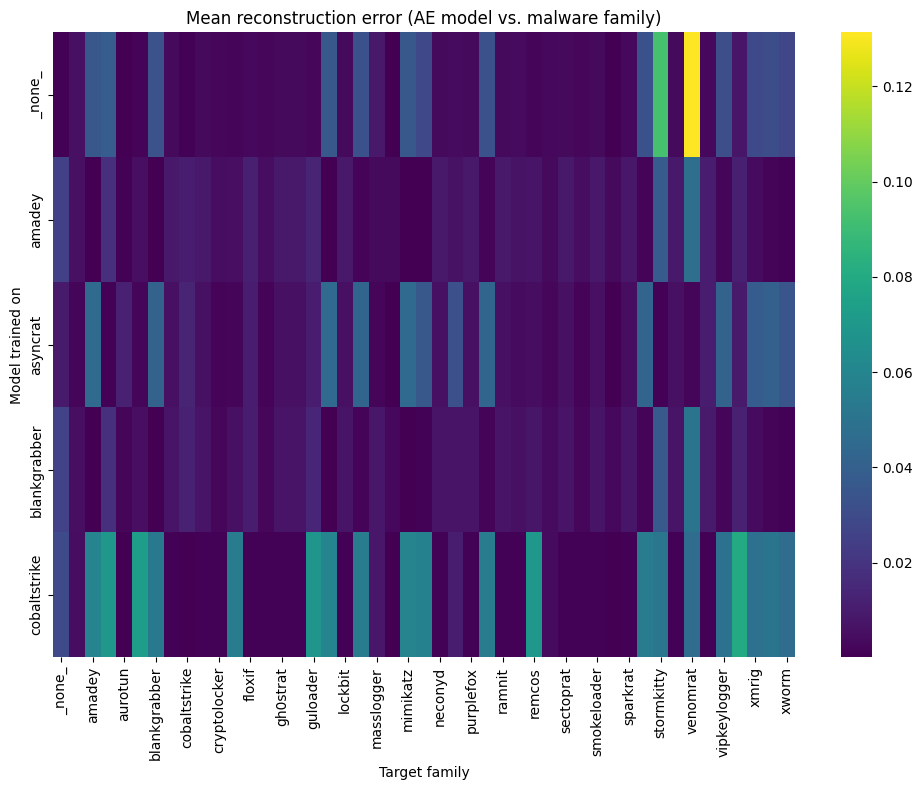

In [10]:
pivot_mean = df_eval.pivot(index="model_family", columns="target_family", values="mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=False, cmap="viridis")
plt.title("Mean reconstruction error (AE model vs. malware family)")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()

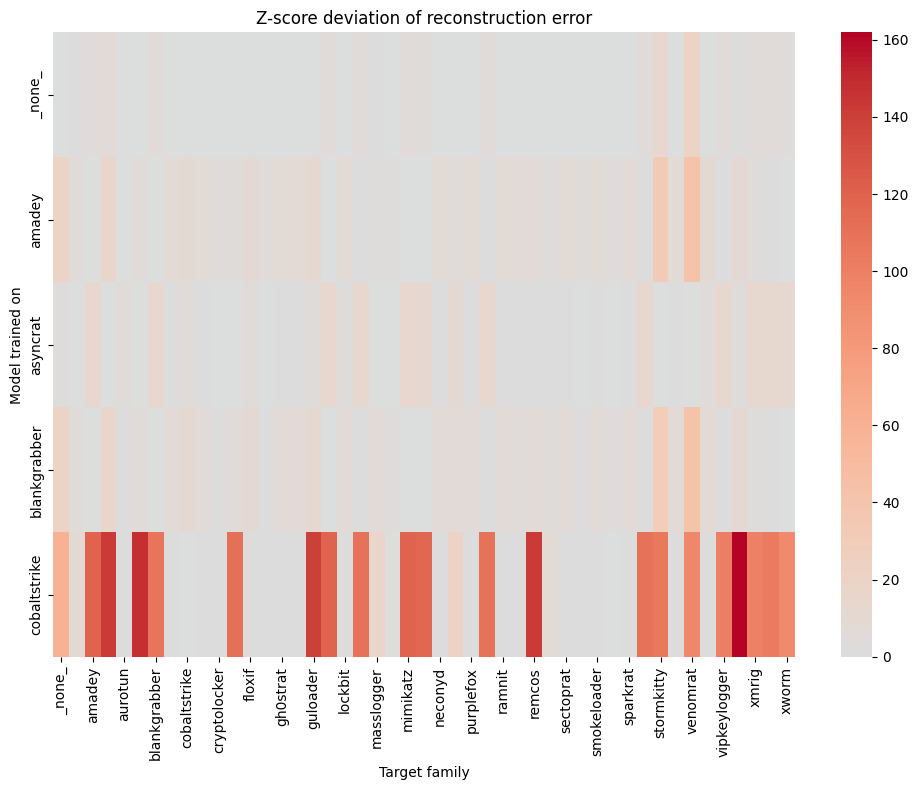

In [11]:
pivot_z = df_eval.pivot(index="model_family", columns="target_family", values="z_mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_z, annot=False, cmap="coolwarm", center=0)
plt.title("Z-score deviation of reconstruction error")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()